# Explicabilidad de préstamos

Entrenamos un Random Forest y exploramos sus predicciones con SHAP. Ejecuta las celdas en orden desde VS Code con la extensión de Colab.

## Librerías

Instalamos las herramientas del laboratorio, incluido LIME para las siguientes etapas.

In [1]:
%pip install -q pandas scikit-learn "shap>=0.45" lime matplotlib

Note: you may need to restart the kernel to use updated packages.


## Etapa 2: Cargar y explorar los datos

`Loan_Status` indica si el préstamo fue aprobado (`Y`) o denegado (`N`). Revisamos los datos faltantes y quitamos `Loan_ID`, que solo identifica cada solicitud.

In [2]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

url = "https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv"
df = pd.read_csv(url)
display(df.head())
print("Datos faltantes por columna:\n", df.isna().sum())
df = df.drop(columns="Loan_ID")

/tmp/ml-notebook-check/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Datos faltantes por columna:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


## Etapa 3: Preparar los datos

Usamos el 80 % para entrenar y el 20 % para probar; la semilla 42 permite repetir la división. Rellenamos números con la mediana y categorías con la moda del entrenamiento, y convertimos cada categoría en una columna de 0 y 1.

In [3]:
X = df.drop(columns="Loan_Status")
y = df["Loan_Status"].map({"Y": 1, "N": 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(exclude="number").columns

# Aprendemos los valores de relleno solo del entrenamiento.
relleno = X_train[num_cols].median().to_dict()
relleno.update(X_train[cat_cols].mode().iloc[0].to_dict())
X_train = X_train.fillna(relleno)
X_test = X_test.fillna(relleno)

X_train_prep = pd.get_dummies(X_train, columns=cat_cols, dtype=int)
X_test_prep = pd.get_dummies(X_test, columns=cat_cols, dtype=int)
# Usamos exactamente las columnas del entrenamiento, en el mismo orden.
X_test_prep = X_test_prep.reindex(columns=X_train_prep.columns, fill_value=0)

print("Entrenamiento:", X_train_prep.shape)
print("Prueba:", X_test_prep.shape)

Entrenamiento: (491, 20)
Prueba: (123, 20)


## Etapa 4: Entrenar y evaluar

Accuracy mide la proporción total de aciertos. F1 combina precisión y capacidad de detectar los préstamos aprobados (clase 1); ambas métricas van de 0 a 1 y los valores más altos son mejores.

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_prep, y_train)
y_pred = rf_model.predict(X_test_prep)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.7642
F1-Score: 0.8380


En esta ejecución, el modelo acertó el 76.42 % de las solicitudes de prueba. El F1 de 0.8380 resume su desempeño al identificar aprobaciones, pero no significa que acierte el 83.80 % de todos los casos. Estas métricas no demuestran que el modelo sea justo.

## Etapa 5: Explicación global con SHAP

Explicamos la clase aprobado (1): cada punto es una solicitud y las variables más influyentes aparecen arriba. Los valores SHAP positivos favorecen la aprobación y los negativos la reducen; rojo indica valores altos de la variable y azul, bajos.

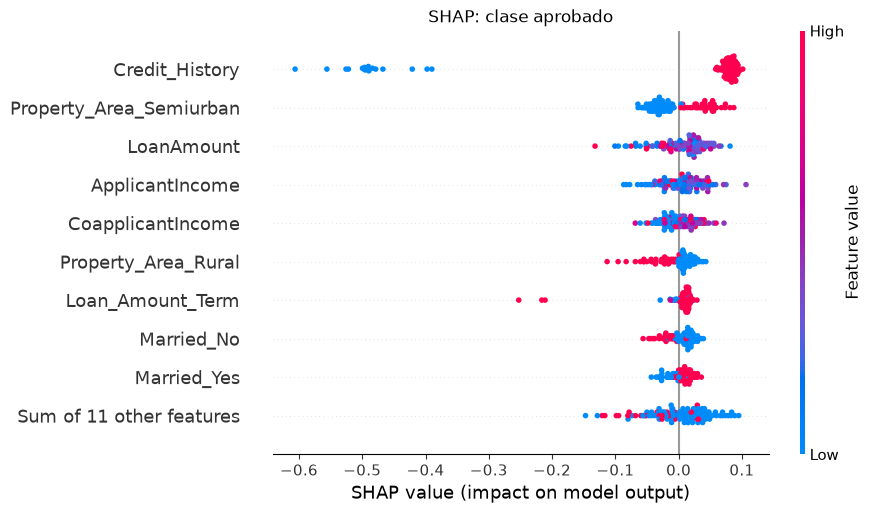

In [5]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test_prep)
clase_aprobado = list(rf_model.classes_).index(1)
shap_values_aprobado = shap_values[:, :, clase_aprobado]

shap.plots.beeswarm(shap_values_aprobado, show=False)
plt.title("SHAP: clase aprobado")
plt.show()

In [6]:
importancia = pd.Series(
    abs(shap_values_aprobado.values).mean(axis=0),
    index=X_test_prep.columns
).sort_values(ascending=False)
display(importancia.head(3).rename("Importancia SHAP"))

Credit_History             0.144436
Property_Area_Semiurban    0.034918
LoanAmount                 0.029551
Name: Importancia SHAP, dtype: float64

**Las tres variables principales:** `Credit_History`, `Property_Area_Semiurban` y `LoanAmount`. En el gráfico, un historial codificado como 1 favorece la aprobación, mientras que 0 la reduce; pertenecer a una zona semiurbana también suele favorecerla. El monto del préstamo tiene efectos más mezclados: algunos montos altos reducen la aprobación, pero no se observa una regla única para todas las solicitudes.

## Etapa 6: Elegir dos solicitudes

Elegimos el primer caso que el modelo aprueba y el primero que deniega en prueba. El índice identifica la fila original; la probabilidad corresponde a la clase predicha y no garantiza que la decisión sea correcta.

In [7]:
predicciones = pd.Series(y_pred)
assert 1 in predicciones.values and 0 in predicciones.values
pos_aprobado = predicciones[predicciones == 1].index[0]
pos_denegado = predicciones[predicciones == 0].index[0]
clase_denegado = list(rf_model.classes_).index(0)
probabilidades = rf_model.predict_proba(X_test_prep)

casos = pd.DataFrame({
    "Índice original": X_test_prep.index[[pos_aprobado, pos_denegado]],
    "Predicción": ["Aprobado", "Denegado"],
    "Probabilidad": [probabilidades[pos_aprobado, clase_aprobado],
                     probabilidades[pos_denegado, clase_denegado]]
})
display(casos)

,Índice original,Predicción,Probabilidad
0,350,Aprobado,0.74
1,77,Denegado,0.52


## Etapa 7: Explicación local con SHAP

El Waterfall explica la solicitud aprobada. Parte del valor base del modelo y suma los aportes: los positivos aumentan la probabilidad de aprobación y los negativos la reducen.

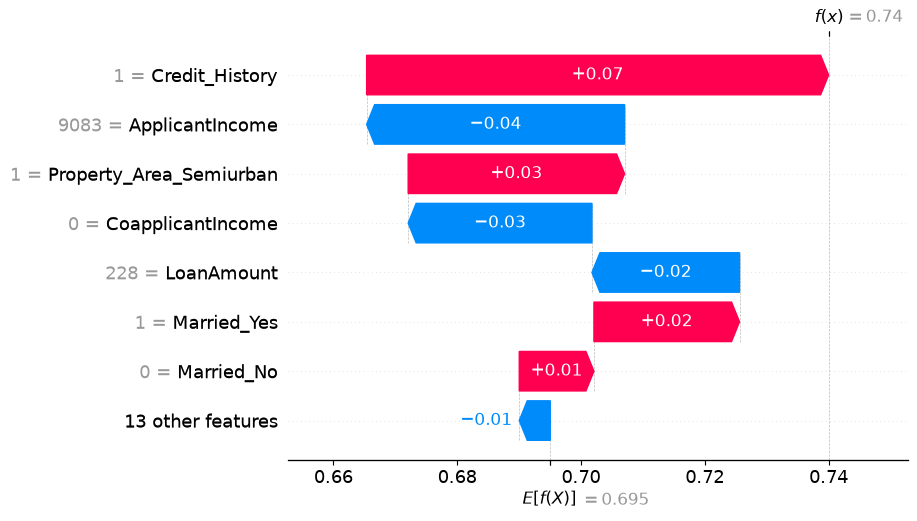

ApplicantIncome           -0.041675
CoapplicantIncome         -0.029690
LoanAmount                -0.023844
Dependents_2              -0.011528
Dependents_0              -0.011312
Self_Employed_Yes         -0.007430
Gender_Male               -0.006506
Self_Employed_No          -0.005779
Gender_Female             -0.003229
Dependents_3+             -0.002012
Education_Graduate         0.004151
Education_Not Graduate     0.004387
Dependents_1               0.006303
Loan_Amount_Term           0.008176
Property_Area_Rural        0.009516
Property_Area_Urban        0.010249
Married_No                 0.012066
Married_Yes                0.023523
Property_Area_Semiurban    0.034963
Credit_History             0.074639
Name: Aporte a la aprobación, dtype: float64

In [8]:
shap.plots.waterfall(shap_values_aprobado[pos_aprobado], max_display=8)
aportes = pd.Series(shap_values_aprobado[pos_aprobado].values,
                    index=X_test_prep.columns)
display(aportes.sort_values().rename("Aporte a la aprobación"))

**Para la persona solicitante (fila 350):** el modelo estima un 74 % de probabilidad de aprobación, frente a un valor base cercano al 69.5 %. El historial crediticio registrado como 1 y la zona semiurbana aumentan esa predicción; los ingresos del solicitante, los del cosolicitante y el monto solicitado la reducen en este caso. Son asociaciones aprendidas por el modelo, no causas ni una decisión de un banco real.

## Etapa 8: Explicación local con LIME

LIME aproxima el modelo cerca de la solicitud denegada y muestra seis factores. Un peso positivo favorece la denegación y uno negativo se opone; estos pesos no son probabilidades ni se comparan directamente con SHAP.

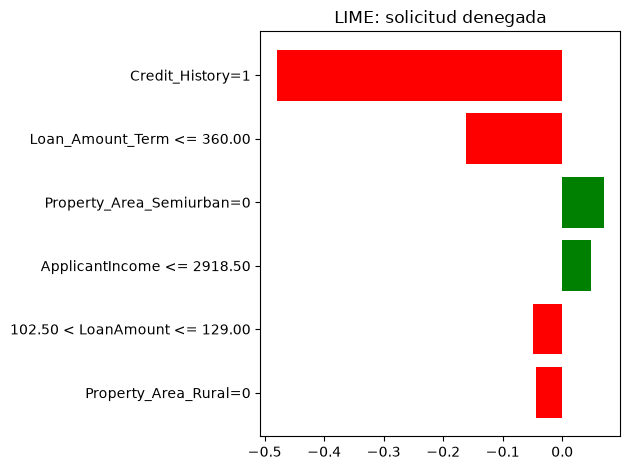

,Factor,Peso hacia la denegación
0,Credit_History=1,-0.479488
1,Loan_Amount_Term <= 360.00,-0.161603
2,Property_Area_Semiurban=0,0.069674
3,ApplicantIncome <= 2918.50,0.049106
4,102.50 < LoanAmount <= 129.00,-0.048489
5,Property_Area_Rural=0,-0.044678


Ajuste local de LIME (R²): 0.762


In [9]:
from lime.lime_tabular import LimeTabularExplainer

columnas = X_train_prep.columns
categoricas = [i for i, columna in enumerate(columnas)
               if X_train_prep[columna].nunique() == 2]
lime_explainer = LimeTabularExplainer(
    X_train_prep.to_numpy(dtype=float),
    feature_names=list(columnas),
    class_names=["Denegado", "Aprobado"],
    categorical_features=categoricas,
    mode="classification", random_state=42
)

# LIME entrega arrays; el modelo espera las columnas del entrenamiento.
def predecir_probabilidad(datos):
    return rf_model.predict_proba(pd.DataFrame(datos, columns=columnas))

lime_caso = lime_explainer.explain_instance(
    X_test_prep.iloc[pos_denegado].to_numpy(dtype=float),
    predecir_probabilidad, labels=(clase_denegado,), num_features=6
)
lime_caso.as_pyplot_figure(label=clase_denegado)
plt.title("LIME: solicitud denegada")
plt.tight_layout()
plt.show()
display(pd.DataFrame(lime_caso.as_list(label=clase_denegado),
                     columns=["Factor", "Peso hacia la denegación"]))
print(f"Ajuste local de LIME (R²): {lime_caso.score:.3f}")

**Para la persona solicitante (fila 77):** el modelo estima un 52 % de probabilidad de denegación, muy cerca del límite de decisión. Según la aproximación de LIME, no estar en una zona semiurbana y los ingresos bajos favorecen la denegación; el historial registrado como 1 y el plazo del préstamo se oponen. La explicación es aproximada y no reproduce necesariamente la probabilidad del modelo: no debemos tomarla como una justificación completa ni como una decisión de un banco real.

LIME genera solicitudes artificiales alrededor del caso. Al modificar por separado las columnas de una categoría, puede crear combinaciones que no existen; por eso esta explicación es una aproximación para aprender, no una justificación definitiva.

El R² indica cuánto se ajusta la explicación al modelo en las muestras artificiales: cuanto más cerca de 1, mejor. Un valor bajo limita la confianza en los factores mostrados.

## Etapa 9: Reflexión ética

Revisamos las variables de género y estado civil dentro de la importancia global; un valor mayor indica más influencia promedio, no discriminación por sí sola.

In [10]:
sensibles = importancia.index.str.startswith(("Gender_", "Married_"))
display(importancia[sensibles].rename("Importancia SHAP"))

Married_No       0.016230
Married_Yes      0.013347
Gender_Male      0.005011
Gender_Female    0.004042
Name: Importancia SHAP, dtype: float64

El estado civil y el género tienen aportes SHAP distintos de cero, aunque menores que el historial crediticio en esta ejecución. Esto merece revisión, pero por sí solo no prueba discriminación; otras variables, como la zona de residencia, también podrían reflejar desigualdades. Un rechazo incorrecto puede perjudicar a un solicitante. Antes de un uso real habría que revisar la calidad y representatividad de los datos, comparar errores y tasas de aprobación entre grupos, comprobar la estabilidad de las explicaciones y contar con revisión humana y una forma de apelar.